In [1]:
import torchvision
from torchvision import transforms

# MNIST dataset
root_path = '/home/storopoli/Downloads' # mude isso no Colab se necessário

# Pequena transformação para tensores e normalizando o tamanho
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Train/Test Datasets
train_dataset = torchvision.datasets.FashionMNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root=root_path, train=False, transform=trans)

In [2]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: /home/storopoli/Downloads
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [3]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [4]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: /home/storopoli/Downloads
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [5]:
from torch.utils.data import DataLoader

batch_size=32

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
import torch.nn as nn

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc1 = nn.Sequential(
            nn.Linear(7 * 7 * 64, 1000),
            nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)
    
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instancia o Model()
model = ConvNet()

print(model)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(model)

3199106

In [8]:
from torch.optim import Adam, SGD 

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 10

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)
#optimizer = SGD(model.parameters(), lr=learning_rate)


In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


True
NVIDIA GeForce RTX 3050 Laptop GPU


ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)

In [10]:
# Treinar o Modelo
total_step = len(train_loader) # quantos batches eu tenho

# Listas vazias
train_loss_epoch_list = []
train_acc_epoch_list = []

val_loss_list = []
val_acc_list = []

best_val_acc = 0

for epoch in range(epochs):
    model.train()  # Coloca o modelo em modo de treino

    train_loss = 0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):

        images, labels = images.to(device), labels.to(device)

        # Gera a propagação (feed forward)
        outputs = model(images)

        # Calcula a função-custo
        loss = loss_fn(outputs, labels)

        # Retro-propagação (Backprop) e a otimização com Adam
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Acurácia
        train_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo: {round(loss.item(), 3)}, Acurácia: {round((correct / total) * 100, 3)}")

    # Média por época
    epoch_train_acc = correct / total
    epoch_train_loss = train_loss / len(train_loader)

    train_loss_epoch_list.append(epoch_train_loss)
    train_acc_epoch_list.append(epoch_train_acc)

   # ======= Loop de validação =======
    model.eval()  # Coloca o modelo em modo de avaliação

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            
            images, labels = images.to(device), labels.to(device)

            # Feed-forward com as imagens de teste
            outputs = model(images)

            # Calcula a função-custo
            loss = loss_fn(outputs, labels)


            # Acurácia
            val_loss += loss.item() * images.size(0)
            total += labels.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

    # Cálculos finais da época
    avg_val_loss = val_loss / len(validation_loader)
    val_accuracy = correct / total

    val_loss_list.append(avg_val_loss)
    val_acc_list.append(val_accuracy)

    print(f"[Validação] Época {epoch+1} -> Loss: {round(avg_val_loss, 3)}, Acurácia: {round(val_accuracy * 100, 3)}%")


Época [1/10], Step [100/1500], Custo: 0.511, Acurácia: 70.906
Época [1/10], Step [200/1500], Custo: 0.416, Acurácia: 76.062
Época [1/10], Step [300/1500], Custo: 0.568, Acurácia: 78.792
Época [1/10], Step [400/1500], Custo: 0.63, Acurácia: 80.289
Época [1/10], Step [500/1500], Custo: 0.174, Acurácia: 81.619
Época [1/10], Step [600/1500], Custo: 0.183, Acurácia: 82.297
Época [1/10], Step [700/1500], Custo: 0.553, Acurácia: 83.098
Época [1/10], Step [800/1500], Custo: 0.408, Acurácia: 83.551
Época [1/10], Step [900/1500], Custo: 0.375, Acurácia: 83.924
Época [1/10], Step [1000/1500], Custo: 0.258, Acurácia: 84.344
Época [1/10], Step [1100/1500], Custo: 0.742, Acurácia: 84.739
Época [1/10], Step [1200/1500], Custo: 0.47, Acurácia: 85.031
Época [1/10], Step [1300/1500], Custo: 0.254, Acurácia: 85.305
Época [1/10], Step [1400/1500], Custo: 0.223, Acurácia: 85.567
Época [1/10], Step [1500/1500], Custo: 0.345, Acurácia: 85.79
[Validação] Época 1 -> Loss: 9.142, Acurácia: 89.35%
Época [2/10], 

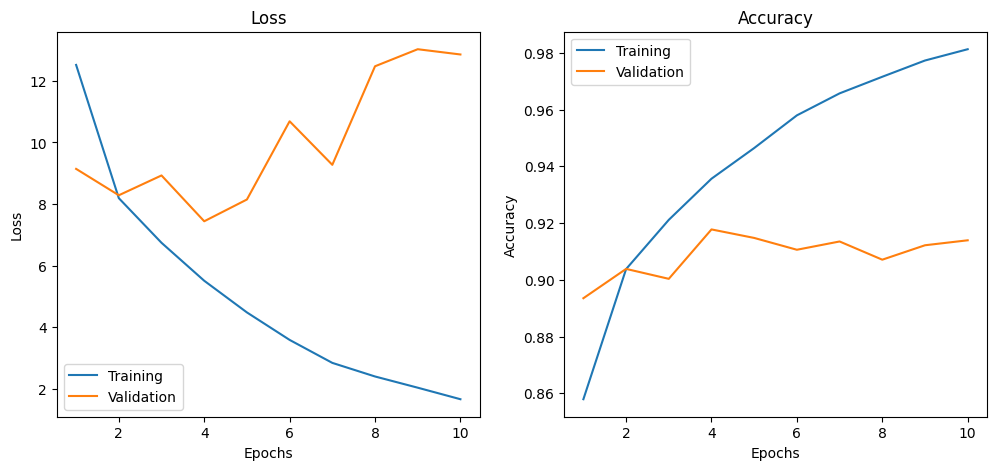

In [11]:
import matplotlib.pyplot as plt

# ======== Plot dos gráficos de perda e acurácia ========
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_epoch_list, label='Training')
plt.plot(epochs_range, val_loss_list, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_epoch_list, label='Training')
plt.plot(epochs_range, val_acc_list, label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.show()

In [12]:
model.eval() # coloca o modelo em modo de avaliação (sem calcular gradientes)

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)
        # Feed-forward com as imagens de teste
        outputs = model(images)
        
        # gera predições usando a função max()
        _, predicted = torch.max(outputs.data, 1)
        
        # Acumula total e corretas
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    print(f"Acurácia do Modelo em 10k imagens de teste: {round((correct / total) * 100, 3)}")

Acurácia do Modelo em 10k imagens de teste: 91.24
